#Equation of State Inference Pipeline

## Load Datasets

We load our libraries and datasets. The datasets are merged into mass-radius, mass-radius-k2 and test sets respectively. The columns of the dataset are also named here. This is done according to the construction of the dataset in the generate_data file.

For the mass radius dataset, column 0 corresponds to the EOS label. Column 1 will denote the lambda value. Columns 2-8 will denote 7 values of the mass density, used for speed of sound parametrization. Columns 9-15 contain 7 values for the speed of sound, and columns 16-30 contain 15 values for the masses $M$ on the MR-curve (Mass-Radius curve). Lastly, columns 39-45 denote 15 values for the radius $R$ on the MR-curve.

For the dataset including the tidal love number $k_2$, we extend our dataset and let the columns 46-60 describe our 15 values for the love number.

For this model, we have chosen 30 observation points from each MR curve. The number of repetitions for each point is chosen to be 300 for our train sets and 100 for the test set.

In [1]:
#Public libraries
import tensorflow as tf
import numpy as np
import statistics
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model

#Custom libraries
from models import *
from deterministic_plots import *
from bayesian_plots import *
from feature_importance import *
import TOV_solver as ts

In [2]:
#Mass Radius data
df_MR_ap4 = pd.read_csv("/content/dataset_30points_larger300_ap4.csv", sep=r"\s+", header=None)
df_MR_sly = pd.read_csv("/content/dataset_30points_larger300_sly.csv", sep=r"\s+", header=None)

#Mass Radius k2 data
df_MRk2_ap4 = pd.read_csv("/content/datasetk2_30points_larger300_ap4.csv", sep=r"\s+", header=None)
df_MRk2_sly = pd.read_csv("/content/datasetk2_30points_larger300_sly.csv", sep=r"\s+", header=None)

#test set
dftest_ap4 = pd.read_csv("/content/datasetk2_30points_Test_100_ap4.csv", sep=r"\s+", header=None)
dftest_sly = pd.read_csv("/content/datasetk2_30points_Test_100_sly.csv", sep=r"\s+", header=None)

df_MR = pd.concat([df_MR_ap4, df_MR_sly])
df_MRk2 = pd.concat([df_MRk2_ap4, df_MRk2_sly])
dftest = pd.concat([dftest_ap4, dftest_sly])

#set column names
cols = (["eos", "Lambda"]
    + [f"rho{i}" for i in range(1,8)]
    + [f"cs{i}" for i in range(1,8)]
    + [f"M{i}" for i in range(1,31)]
    + [f"R{i}" for i in range(1,31)])

cols_k2 = cols + [f"k2{i}" for i in range(1,31)]

df_MR.columns = cols
df_MRk2.columns = cols_k2
dftest.columns = cols_k2

## MR curve preprocessing

We preprocess our data by shuffling our dataset to avoid overfitting. Furthermore, we filter by removing data containing negative (unphysical) masses. We proceed by splitting our features and targets.

In [3]:
#Shuffle dataset
df_MR = df_MR.sample(frac=1).reset_index(drop=True)

X, yeos, y = df_MR.iloc[:,16:76].values, df_MR.iloc[:,0].values, df_MR.iloc[:,1:16].values

#filter MR curves
indices = []
for i in range(0,len(X)): #rows
    for j in range(0,len(X[1])): #columns
        if X[i,j] < 0:
            indices.append(i)
            break

X, yeos, y = np.delete(X,indices,axis=0), np.delete(yeos,indices,axis=0), np.delete(y,indices,axis=0)

Next we LabelEncode column 0, since they contain either AP4 or SLy. We can map these strings to integers 0 and 1, such that we can feed this classification to our models. Furthermore, the necessary columns are normalized.

In [4]:
#LabelEncode AP4 and SLy datasets to integers 0 and 1
yeos[:] = LabelEncoder().fit_transform(yeos)

#Normalize columns
y[:,0] = (y[:,0] + 194.)/388.
y[:,1:8] /= y[0,7]

Here, the output for our classification model is defined (either SLy or AP4 EoS).

In [5]:
yclass = np.empty([len(yeos), 2])

for i in range(0,len(yeos)):
    #first value is SLy class, second value is AP4 class
    yclass[i] = [yeos[i], 1 - yeos[i]]

In [6]:
#split dataset into train and test sets
X_train, X_test, yclass_train, yclass_test, y_train, y_test = train_test_split(X, yclass, y, test_size=0.33)
print(X_train.shape, X_test.shape, yclass_train.shape, yclass_test.shape, y_train.shape, y_test.shape)

(173858, 60) (85633, 60) (173858, 2) (85633, 2) (173858, 15) (85633, 15)


## Train classification network

The classification network predicts which low-density EOS, AP4 or SLy, generated the input data. In our implementation, the class labels are encoded as two-component vectors, corresponding to the two possible EOS classes. The model is trained using the binary cross-entropy loss,
\begin{equation}
L_{\mathrm{BCE}}
=
-\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i \log(p_i) + (1-y_i)\log(1-p_i)
\right],
\end{equation}
where $y_i$ is the true class label and $p_i$ is the predicted probability. Binary accuracy is used as the training metric.

For the mass–radius input, our implementation used a single hidden layer with 270 nodes. The hidden layer uses ReLU activation and the output layer uses the sigmoid activation.

Evaluation cycle: 0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.5437 - loss: 0.6864 - val_binary_accuracy: 0.6210 - val_loss: 0.6703
Epoch 2/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - binary_accuracy: 0.6391 - loss: 0.6489 - val_binary_accuracy: 0.6148 - val_loss: 0.6295
Epoch 3/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.7323 - loss: 0.5800 - val_binary_accuracy: 0.7346 - val_loss: 0.5540
Epoch 4/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - binary_accuracy: 0.7633 - loss: 0.5263 - val_binary_accuracy: 0.7910 - val_loss: 0.4981
Epoch 5/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.7767 - loss: 0.4920 - val_binary_accuracy: 0.7924 - val_loss: 0.4719
Epoch 6/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - binary_accuracy: 0.7870 - loss: 0.4683 - val_binary_accuracy: 0.7712 - val_loss: 0.4817
Epoch 7/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - binary_accuracy: 0.7915 - loss: 0.4553 - val_binary_accuracy: 0.8066 - val_loss:

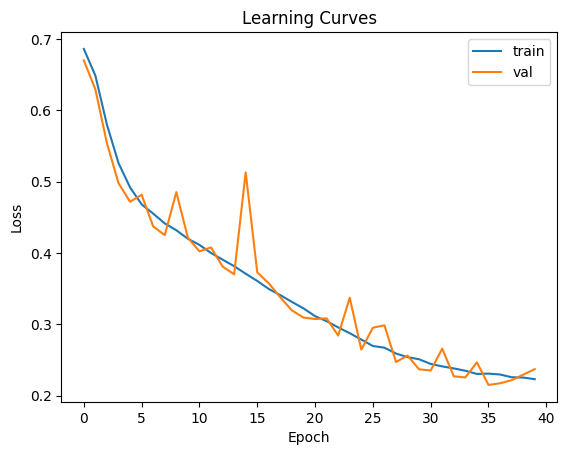

<Figure size 640x480 with 0 Axes>

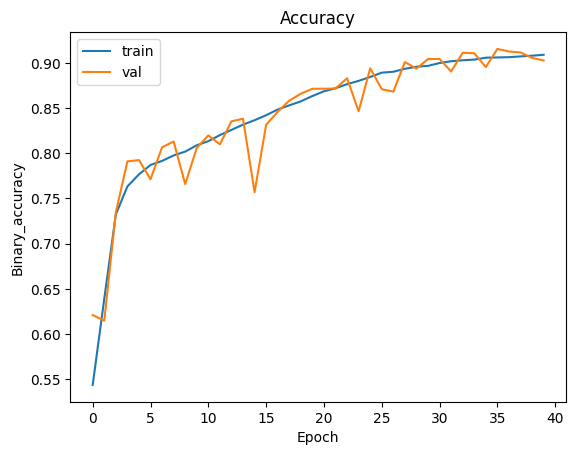

Evaluation cycle: 1
Epoch 1/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.5564 - loss: 0.6828 - val_binary_accuracy: 0.6361 - val_loss: 0.6647
Epoch 2/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.6566 - loss: 0.6365 - val_binary_accuracy: 0.7141 - val_loss: 0.6012
Epoch 3/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - binary_accuracy: 0.7382 - loss: 0.5670 - val_binary_accuracy: 0.7863 - val_loss: 0.5273
Epoch 4/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.7718 - loss: 0.5138 - val_binary_accuracy: 0.7936 - val_loss: 0.4875
Epoch 5/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - binary_accuracy: 0.7810 - loss: 0.4826 - val_binary_accuracy: 0.7838 - val_loss: 0.4723
Epoch 6/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - binary_accuracy: 0.7912 - loss: 0.4600 - val_binary_accuracy: 0.8064 - val_loss: 0.4415
Epoch 7/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - binary_accuracy: 0.7978 - loss: 0.4444 - val_binary_accuracy

<Figure size 640x480 with 0 Axes>

In [7]:
points = 30
rep = 300

n_features = X.shape[1] #number of features
loss_list, acc_list, val_loss_list, val_acc_list = [], [], [], []
last_acc = 0.
n_nodes = 1
nodes1, nodes2, nodes3 = 270, 0, 0 #Neural network nodes
activation_hidden = 'relu'
ke_init = 'he_normal'
activation_out = 'sigmoid'
ke_init_out = 'glorot_uniform'
N_cycles = 3 #Amount of evaluation cycles

for x in range(N_cycles):
    print('Evaluation cycle:',x)

    model = produce_model_class(n_nodes, nodes1, nodes2, nodes3, activation_hidden,
                              ke_init, activation_out, ke_init_out, n_features)
    #Model compiling
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
    #Model Fitting
    history = model.fit(X, yclass, epochs=40, batch_size=100, verbose=1,
                        validation_split = 0.2)

    #Store last value of loss, accuracy, validation loss, and validation accuracy
    store_values_class(loss_list, val_loss_list, acc_list, val_acc_list, history)

    #Save best model with learning curve
    if history.history['binary_accuracy'][-1] > last_acc:
        print('Saving model at cycle:', x)
        model.save(f'modelClass_n{rep}_N{points}_{nodes1}_{nodes2}_{nodes3}.keras')
        last_acc = history.history['binary_accuracy'][-1]

        #Plot learning curves and save
        plot_learning_curve_class(history, rep, points, nodes1, nodes2, nodes3,
                                check_k2 = False)

        #Plot accuracy and save
        plot_accuracy(history, rep, points, nodes1, nodes2, nodes3, check_k2 = False)

#These are computed for when necessary
acc_mean, acc_stdv = statistics.mean(acc_list), statistics.pstdev(acc_list)
val_acc_mean, val_acc_stdv = statistics.mean(val_acc_list), statistics.pstdev(val_acc_list)
loss_mean, loss_stdv = statistics.mean(loss_list), statistics.pstdev(loss_list)
val_loss_mean,val_loss_stdv=statistics.mean(val_loss_list),statistics.pstdev(val_loss_list)

In the plots above you can see that this model works well; we can accurately classify for MR data whether the EOS for the low-density area is based on AP4 or SLy. The accuracy of the classification network lies around 90%.

## Train regression network

The regression network predicts the remaining EOS parameters,
\begin{equation}
(\rho_1,\rho_2,\dots,\rho_7,\,
c_{s,1},c_{s,2},\dots,c_{s,7},\,
\Lambda),
\end{equation}
where $\rho_i$ are the density points defining the high-density parametrization, $c_{s,i}$ are the corresponding speed-of-sound values, and $\Lambda$ denotes the vacuum energy shift. Before training, these parameters are normalized to the interval $(0,1)$.

The regression model is trained with the mean squared logarithmic error (MSLE),
\begin{equation}
L_{\mathrm{MSLE}}
=
\frac{1}{N}\sum_{i=1}^{N}
\left[
\log(1+y_i)-\log(1+\hat{y}_i)
\right]^2,
\end{equation}
where $y_i$ and $\hat{y}_i$ are the true and predicted target values, respectively.

For the mass-radius-only case, our implementation used a single hidden layer with 90 nodes. As in the classification model, the hidden layers use ReLU activations and the output layer uses sigmoid activation.

Evaluation cycle: 0
Epoch 1/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0165 - val_loss: 0.0163
Epoch 2/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0162 - val_loss: 0.0163
Epoch 3/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 4/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 5/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0161 - val_loss: 0.0161
Epoch 6/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0161 - val_loss: 0.0160
Epoch 7/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0160 - val_loss: 0.0160
Epoch 8/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0160 - val_loss: 0.0160
Epoch 9/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0159 - val_loss: 0.0159
Epoch 10/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0159 - val_loss: 0.0159
Epoch 11/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0159 - val_loss: 0.0159
Epoch 12/3

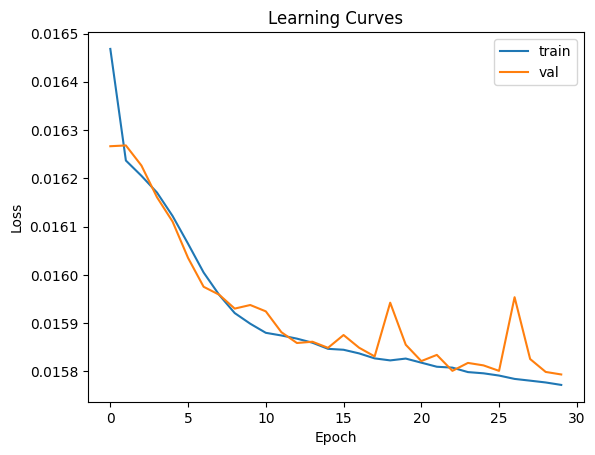

Evaluation cycle: 1
Epoch 1/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0164 - val_loss: 0.0163
Epoch 2/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 3/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 4/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 5/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0161 - val_loss: 0.0161
Epoch 6/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0161 - val_loss: 0.0160
Epoch 7/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0160 - val_loss: 0.0160
Epoch 8/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0160 - val_loss: 0.0159
Epoch 9/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0159 - val_loss: 0.0160
Epoch 10/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0159 - val_loss: 0.0159
Epoch 11/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0159 - val_loss: 0.0160
Epoch 12/3

<Figure size 640x480 with 0 Axes>

In [8]:
#regression model
loss_list, val_loss_list = [], []
last_loss = 1
nodes = 90
activation_hidden = 'relu'
ke_init = 'he_normal'
activation_out = 'sigmoid'
ke_init_out = 'glorot_uniform'
N_cycles = 2 #Amount of evaluation cycles

for x in range(N_cycles):
    print('Evaluation cycle:',x)
    #create model
    model = produce_model_reg(nodes, activation_hidden, ke_init, activation_out,
                              ke_init_out, n_features)

    #compile model
    model.compile(optimizer='adam', loss='msle')

    #Fit the model
    history = model.fit(X, y, epochs=30, batch_size=100, verbose=1, validation_split = 0.2)

    #Store last value of loss and validation loss
    store_values_reg(loss_list, val_loss_list, history)

    #Save only best model and plot its learning curves
    if history.history['loss'][-1] < last_loss:
        print('Saving model at cycle:', x)
        model.save(f'modelReg_n{rep}_N{points}_{nodes}.keras')
        last_loss = history.history['loss'][-1]

        #Plot learning curves and save
        plot_learning_curve_reg(history, rep, points, nodes, check_k2 = False)

loss_mean, loss_stdv = statistics.mean(loss_list), statistics.pstdev(loss_list)
val_loss_mean, val_loss_stdv = statistics.mean(val_loss_list), statistics.pstdev(val_loss_list)

The model did not manage to converge to a much lower loss from its initial position. Given our M-R dataset, we thus managed to capture a weak signal for the high-density region of the neutron star.

In [9]:
#Plot the model
plot_model(model, f'modelReg_n{rep}_N{points}_{nodes}.png', show_shapes=True);

## MRk2 data preprocessing

In terms of preprocessing, we take a similar approach to preprocessing for our M-R dataset. However, here we included the $k_2$ dataset. We will subsequently observe how our models perform compared to our previous dataset.

In [10]:
# points and rep.
points = 30
rep = 300

We shuffle our dataset and remove unphysical data based on constraints.

In [11]:
df_MRk2 = df_MRk2.sample(frac=1).reset_index(drop=True)
X, yeos, y = df_MRk2.iloc[:,16:106].values, df_MRk2.iloc[:,0].values, df_MRk2.iloc[:,1:16].values

#drop M-R-k2 curves with negative mass and radius
indices = []
for i in range(0,len(X)): #rows
    for j in range(0,len(X[1])-points): #columns
        if X[i,j] < 0:
            indices.append(i)
            break

X, yeos, y = np.delete(X,indices,axis=0), np.delete(yeos,indices,axis=0), np.delete(y,indices,axis=0)

Here, we LabelEncode column 0 such that we can feed the AP4 and SLy classification of our dataset into the model. We also normalize the necessary columns.

In [12]:
#Labelencoding AP4 and SLy
yeos[:] = LabelEncoder().fit_transform(yeos)
#Normalizing
y[:,0] = (y[:,0] + 194.)/388.
y[:,1:8] /= y[0,7]

k2max = X[:,60:90].max()
k2min = X[:,60:90].min()
X[:,60:90] = renormalize(X[:,60:90], k2min, k2max)

In [13]:
yclass = np.empty([len(yeos), 2])
for i in range(0,len(yeos)):
    #first value is SLy class, second value is AP4 class
    yclass[i] = [yeos[i], 1- yeos[i]]

In [14]:
#Ensure all data are float32 values
X, yclass, y = X.astype('float32'), yclass.astype('float32'), y.astype('float32')
print(X.shape, yclass.shape, y.shape)

(259496, 90) (259496, 2) (259496, 15)


In [15]:
#train test split our dataset
X_train, X_test, yclass_train, yclass_test, y_train, y_test = train_test_split(X, yclass, y, test_size=0.33)
print(X_train.shape, X_test.shape, yclass_train.shape, yclass_test.shape, y_train.shape, y_test.shape)

(173862, 90) (85634, 90) (173862, 2) (85634, 2) (173862, 15) (85634, 15)


## Train classification network on MRk2 data

The classification network predicts which low-density EOS, AP4 or SLy, generated the input data. In our implementation, the class labels are encoded as two-component vectors, corresponding to the two possible EOS classes. The model is trained using the binary cross-entropy loss,
\begin{equation}
L_{\mathrm{BCE}}
=
-\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i \log(p_i) + (1-y_i)\log(1-p_i)
\right],
\end{equation}
where $y_i$ is the true class label and $p_i$ is the predicted probability. Binary accuracy is used as the training metric.

For the mass-radius-tidal-deformability input, we used a deeper architecture with three hidden layers of sizes $270$, $90$, and $90$. The hidden layers use ReLU activation and the output layer uses the sigmoid activation.

Evaluation cycle: 0
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2076/2076 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - binary_accuracy: 0.8153 - loss: 0.3955 - val_binary_accuracy: 0.8529 - val_loss: 0.3338
Epoch 2/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.8485 - loss: 0.3423 - val_binary_accuracy: 0.8539 - val_loss: 0.3271
Epoch 3/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - binary_accuracy: 0.8607 - loss: 0.3190 - val_binary_accuracy: 0.8707 - val_loss: 0.3010
Epoch 4/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.8720 - loss: 0.2966 - val_binary_accuracy: 0.8866 - val_loss: 0.2671
Epoch 5/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.8863 - loss: 0.2685 - val_binary_accuracy: 0.8760 - val_loss: 0.2870
Epoch 6/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.8954 - loss: 0.2499 - val_binary_accuracy: 0.9025 - val_loss: 0.2344
Epoch 7/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.9023 - loss: 0.2342 - val_binary_accuracy: 0.9053 - val_loss: 0.2257
Ep

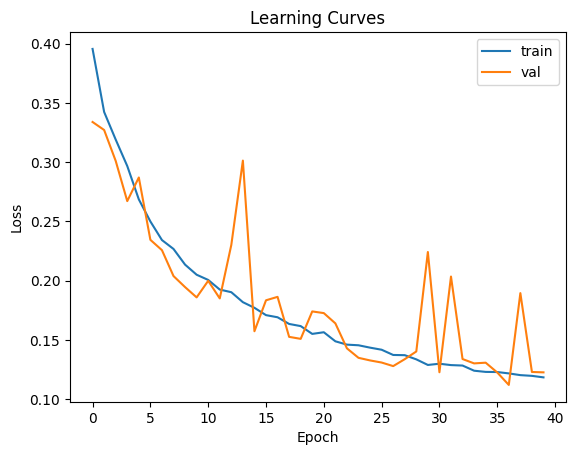

<Figure size 640x480 with 0 Axes>

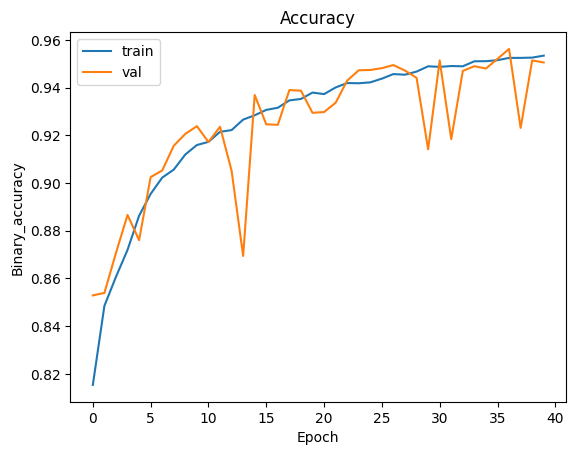

Evaluation cycle: 1
Epoch 1/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - binary_accuracy: 0.8221 - loss: 0.3858 - val_binary_accuracy: 0.8310 - val_loss: 0.3683
Epoch 2/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.8497 - loss: 0.3396 - val_binary_accuracy: 0.8626 - val_loss: 0.3147
Epoch 3/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.8607 - loss: 0.3188 - val_binary_accuracy: 0.8765 - val_loss: 0.2901
Epoch 4/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.8722 - loss: 0.2968 - val_binary_accuracy: 0.8816 - val_loss: 0.2769
Epoch 5/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.8819 - loss: 0.2776 - val_binary_accuracy: 0.8845 - val_loss: 0.2706
Epoch 6/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.8932 - loss: 0.2533 - val_binary_accuracy: 0.9019 - val_loss: 0.2337
Epoch 7/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.9028 - loss: 0.2332 - val_binary_accuracy

<Figure size 640x480 with 0 Axes>

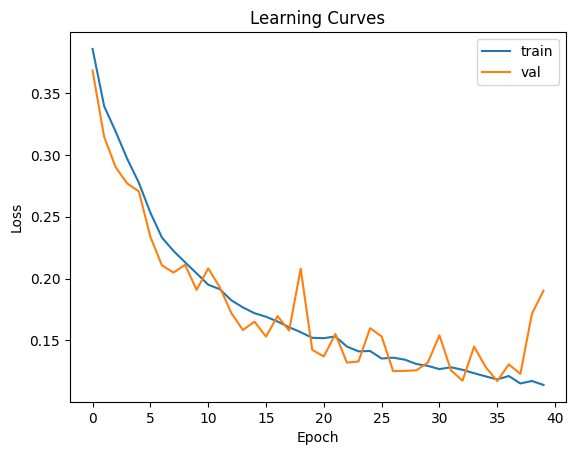

<Figure size 640x480 with 0 Axes>

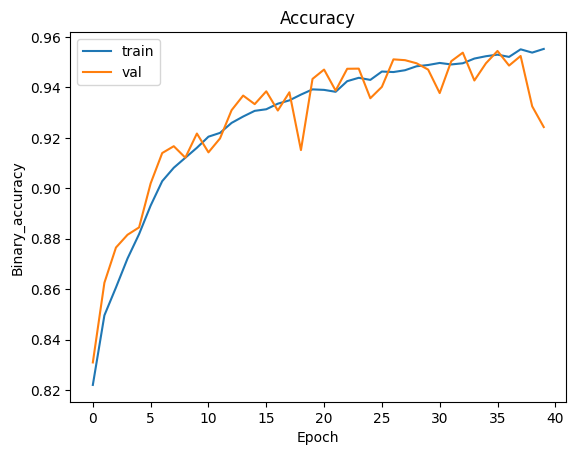

Evaluation cycle: 2
Epoch 1/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.8175 - loss: 0.3939 - val_binary_accuracy: 0.8522 - val_loss: 0.3370
Epoch 2/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.8504 - loss: 0.3379 - val_binary_accuracy: 0.8471 - val_loss: 0.3483
Epoch 3/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - binary_accuracy: 0.8612 - loss: 0.3185 - val_binary_accuracy: 0.8764 - val_loss: 0.2918
Epoch 4/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.8727 - loss: 0.2958 - val_binary_accuracy: 0.8877 - val_loss: 0.2669
Epoch 5/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - binary_accuracy: 0.8840 - loss: 0.2732 - val_binary_accuracy: 0.8864 - val_loss: 0.2693
Epoch 6/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.8956 - loss: 0.2488 - val_binary_accuracy: 0.8938 - val_loss: 0.2512
Epoch 7/40
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - binary_accuracy: 0.9036 - loss: 0.2314 - val_binary_accurac

<Figure size 640x480 with 0 Axes>

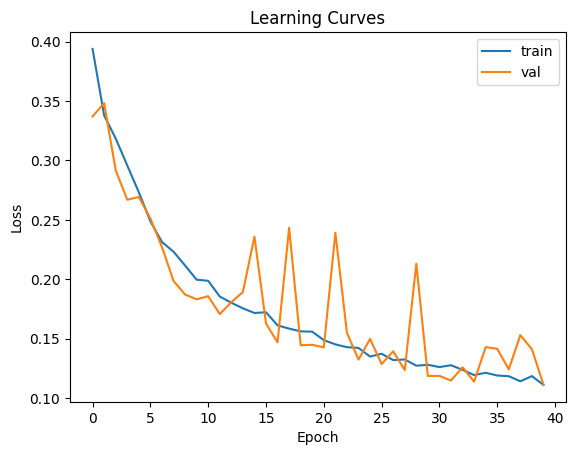

<Figure size 640x480 with 0 Axes>

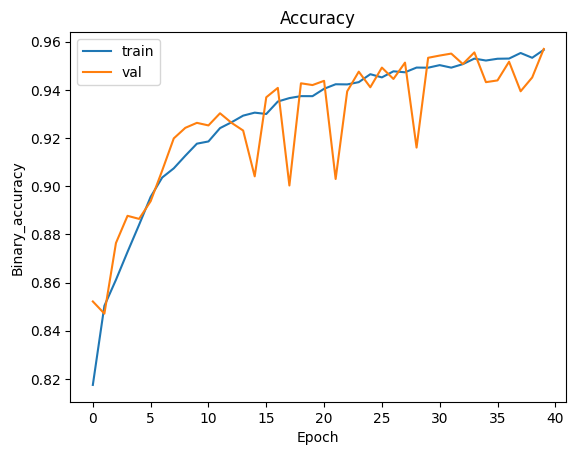

<Figure size 640x480 with 0 Axes>

In [16]:
n_features = X.shape[1] #number of input features
loss_list, acc_list, val_loss_list, val_acc_list = [], [], [], []
last_acc = 0.
n_nodes = 3 #1 #2 #3
nodes1, nodes2, nodes3 = 270, 90, 90
activation_hidden = 'relu'
ke_init = 'he_normal'
activation_out = 'sigmoid'
ke_init_out = 'glorot_uniform'
N_cycles = 3 #Amount of evaluation cycles

for x in range(N_cycles):
    print('Evaluation cycle:',x)

    #create model
    model = produce_model_class(n_nodes, nodes1, nodes2, nodes3, activation_hidden,
                              ke_init, activation_out, ke_init_out, n_features)
    # summarize the model
    #model.summary()

    #Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

    #Fit the model
    history = model.fit(X, yclass, epochs=40, batch_size=100, verbose=1,
                        validation_split = 0.2)

    #Store last value of loss, accuracy, validation loss, and validation accuracy
    store_values_class(loss_list, val_loss_list, acc_list, val_acc_list, history)

    #Save only best model and plot its learning curves
    if history.history['binary_accuracy'][-1] > last_acc:
        print('Saving model at cycle:', x)
        model.save(f'modelClassk2_n{rep}_N{points}_{nodes1}_{nodes2}_{nodes3}.keras')
        last_acc = history.history['binary_accuracy'][-1]

        #Plot learning curves and save
        plot_learning_curve_class(history, rep, points, nodes1, nodes2, nodes3,
                                  check_k2 = True)

        #Plot accuracy and save
        plot_accuracy(history, rep, points, nodes1, nodes2, nodes3, check_k2 = True)

acc_mean, acc_stdv = statistics.mean(acc_list), statistics.pstdev(acc_list)
val_acc_mean, val_acc_stdv = statistics.mean(val_acc_list), statistics.pstdev(val_acc_list)
loss_mean, loss_stdv = statistics.mean(loss_list), statistics.pstdev(loss_list)
val_loss_mean,val_loss_stdv=statistics.mean(val_loss_list),statistics.pstdev(val_loss_list)

In [17]:
#Plot the model
plot_model(model, f'modelClassk2_n{rep}_N{points}_{nodes1}_{nodes2}_{nodes3}.png',
           show_shapes=True);

## Train regression network on MRk2 data

The regression network predicts the remaining EOS parameters,
\begin{equation}
(\rho_1,\rho_2,\dots,\rho_7,\,
c_{s,1},c_{s,2},\dots,c_{s,7},\,
\Lambda),
\end{equation}
where $\rho_i$ are the density points defining the high-density parametrization, $c_{s,i}$ are the corresponding speed-of-sound values, and \(\Lambda\) denotes the vacuum energy shift. Before training, these parameters are normalized to the interval $(0,1)$.

The regression model is trained with the mean squared logarithmic error (MSLE),
\begin{equation}
L_{\mathrm{MSLE}}
=
\frac{1}{N}\sum_{i=1}^{N}
\left[
\log(1+y_i)-\log(1+\hat{y}_i)
\right]^2,
\end{equation}
where $y_i$ and $\hat{y}_i$ are the true and predicted target values, respectively.

For the mass-radius-tidal-deformability case, we used a single hidden layer with 180 nodes. As in the classification model, the hidden layers use ReLU activations and the output layer uses sigmoid activation.

Evaluation cycle: 0
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0164 - val_loss: 0.0162
Epoch 2/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 3/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 4/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0162 - val_loss: 0.0161
Epoch 5/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0161 - val_loss: 0.0161
Epoch 6/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0161 - val_loss: 0.0160
Epoch 7/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0160 - val_loss: 0.0159
Epoch 8/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0160 - val_loss: 0.0159
Epoch 9/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0159 - val_loss: 0.0160
Epoch 10/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0159 - val_loss: 0.0158
Epoch 11/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0159 - val_loss: 0.0159
Epoch 12/30
2076/2076 ━━━━━━━━━━━━━━━━━━━

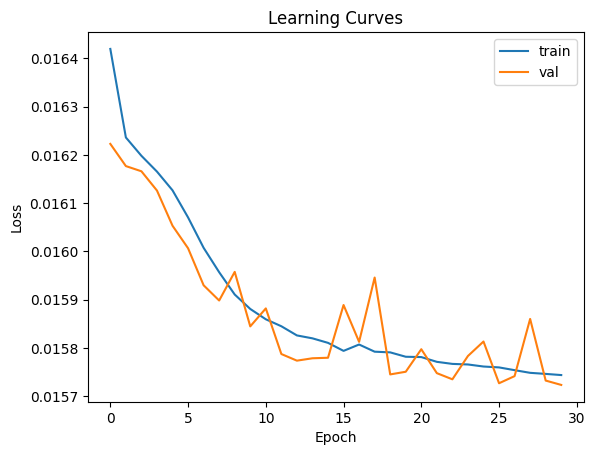

Evaluation cycle: 1
Epoch 1/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0164 - val_loss: 0.0162
Epoch 2/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 3/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0162 - val_loss: 0.0162
Epoch 4/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0162 - val_loss: 0.0161
Epoch 5/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0161 - val_loss: 0.0161
Epoch 6/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0161 - val_loss: 0.0160
Epoch 7/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0160 - val_loss: 0.0159
Epoch 8/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0160 - val_loss: 0.0159
Epoch 9/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0159 - val_loss: 0.0158
Epoch 10/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0159 - val_loss: 0.0158
Epoch 11/30
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0159 - val_loss: 0.0158
Epoch 12/3

<Figure size 640x480 with 0 Axes>

In [18]:
loss_list, val_loss_list = [], []
last_loss = 1
nodes = 180
activation_hidden = 'relu'
ke_init = 'he_normal'
activation_out = 'sigmoid'
ke_init_out = 'glorot_uniform'
N_cycles = 2 #Amount of evaluation cycles

for x in range(N_cycles):
    print('Evaluation cycle:',x)
    #create model
    model = produce_model_reg(nodes, activation_hidden, ke_init, activation_out,
                              ke_init_out, n_features)

    #compile model
    model.compile(optimizer='adam', loss='msle')

    #Fit the model
    history = model.fit(X, y, epochs=30, batch_size=100, verbose=1, validation_split = 0.2)

    #Store last value of loss and validation loss
    store_values_reg(loss_list, val_loss_list, history)

    #Save only best model and plot its learning curves
    if history.history['loss'][-1] < last_loss:
        print('Saving model at cycle:', x)
        model.save(f'modelRegk2_n{rep}_N{points}_{nodes}.keras')
        last_loss = history.history['loss'][-1]

        #Plot learning curves and save
        plot_learning_curve_reg(history, rep, points, nodes, check_k2 = True)

loss_mean, loss_stdv = statistics.mean(loss_list), statistics.pstdev(loss_list)
val_loss_mean, val_loss_stdv = statistics.mean(val_loss_list), statistics.pstdev(val_loss_list)

In [19]:
#Plot the model
plot_model(model, f'modelRegk2_n{rep}_N{points}_{nodes}.png', show_shapes=True);

## Evaluate MRk2 classification and regression models on test set

For the evaluation, we use a generated dataset from our generate_data algorithm, where we use 30 observation points with 100 repetitions of Gaussian noise injections.

In [20]:
points = 30
rep_test = 100

X_test, yeos_test, y_test = dftest.iloc[:,16:106].values, dftest.iloc[:,0].values, dftest.iloc[:,1:16].values

Eliminate unphysical data

In [21]:
#Eliminate those M-R-k2 curves with negative masses and radii
indices = []
for i in range(0,len(X_test)): #rows
    for j in range(0,len(X_test[1])-points): #columns
        if X_test[i,j] < 0:
            indices.append(i)
            break

X_test, yeos_test, y_test  = np.delete(X_test,indices,axis=0), np.delete(yeos_test,indices,axis=0), np.delete(y_test,indices,axis=0)

We also LabelEncode column 0 and normalize our columns for the test set too.

In [22]:
#Labelencode AP4 and SLy dataset column
yeos_test[:] = LabelEncoder().fit_transform(yeos_test)
#Normalize columns
y_test[:,0] = (y_test[:,0] + 194.)/388.
y_test[:,1:8] /= y_test[0,7]

In [23]:
k2max, k2min = 1.66007354312931, -1.57981785098554
X_test[:,60:90] = renormalize(X_test[:,60:90], k2min, k2max)

X_test, yeos_test, y_test = X_test.astype('float32'), yeos_test.astype('float32'), y_test.astype('float32')
print(X_test.shape, yeos_test.shape, y_test.shape)

(6500, 90) (6500,) (6500, 15)


In [24]:
#Load classification model
model_dir = "modelClassk2_n300_N30_270_90_90.keras"
model_class = load_model(model_dir) #insert relevant file. In our case; nodes: 270, 90, 90
model_class.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 270)            │        24,570 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 90)             │        24,390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 90)             │         8,190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │           182 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,998 (671.87 KB)

 Trainable params: 57,332 (223.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 114,666 (447.92 KB)

In [25]:
#Load regresssion model
model_dir = "modelRegk2_n300_N30_180.keras"
model_reg = load_model(model_dir)
model_reg.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 180)            │        16,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │         2,715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,287 (223.78 KB)

 Trainable params: 19,095 (74.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,192 (149.19 KB)

In [26]:
yclass_hat = model_class.predict([X_test])
y_hat = model_reg.predict([X_test])

146/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_7
Received: inputs=('Tensor(shape=(32, 90))',)
  warnings.warn(msg)


204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  1/204 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_7
Received: inputs=('Tensor(shape=(None, 90))',)
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_8
Received: inputs=('Tensor(shape=(32, 90))',)
  warnings.warn(msg)


204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_8
Received: inputs=('Tensor(shape=(None, 90))',)
  warnings.warn(msg)


For the mass-radius-tidal deformability dataset, the test set performance of our classification model determined here.

In [27]:
yeos_hat = []
for i in range(0,len(yclass_hat)):
    if yclass_hat[i,0] > yclass_hat[i,1]:
        yeos_hat.append(1)
    else:
        yeos_hat.append(0)

count = 0
for i in range(0,len(yeos_hat)):
    if yeos_hat[i] == yeos_test[i]:
        count += 1

print(f'The accuracy for the classification model is: {count/len(yeos_hat)}')

The accuracy for the classification model is: 0.918923076923077


Now we plot a couple of evaluation plots on the speed of sound predictions of our regression model. First we plot the predicted against the true speed of sound, then the predicted against the true mean speed of sound.

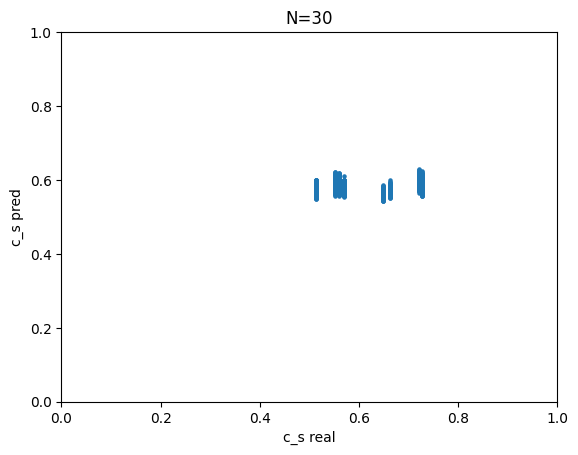

In [28]:
#Plotting the mean value of the speed of sound
stat_test = np.empty([len(y_test), 2]) #mean and standard dev.
stat_hat = np.empty([len(y_hat), 2]) #mean and standard dev.

for i in range(0,len(y_test)):
    stat_test[i] = [statistics.mean(y_test[i,8:15]),statistics.pstdev(y_test[i,8:15])]
    stat_hat[i] = [statistics.mean(y_hat[i,8:15]),statistics.pstdev(y_hat[i,8:15])]

plot_mean_cs(stat_test, stat_hat, points, save = False)

In the plot above we can see that all points lie in a horzontal strip between cs_pred 0.55-0.60. we can see that the predicted speed of sound takes on an approximately constant value, reflecting the underfitting and degeneracy behavior of our results.

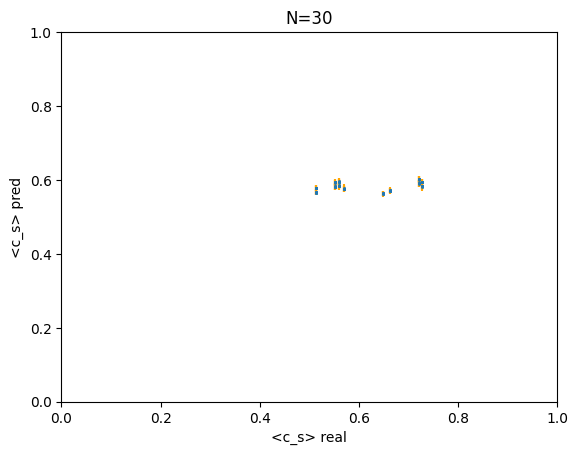

In [29]:
#Plotting true vs predicted mean speed of sound

data_test = np.empty([int(len(stat_test)/rep_test), 2])
data_hat = np.empty([int(len(stat_test)/rep_test), 2])

produce_mean_cs_separate(data_test, data_hat, stat_test, stat_hat, rep_test)

plot_mean_cs_separate(data_test, data_hat, points, save = False)

In the plot above, we demonstrate that the model consistently collapses across our various samples of the same equation of state. This means that we are observing systematic collapse.

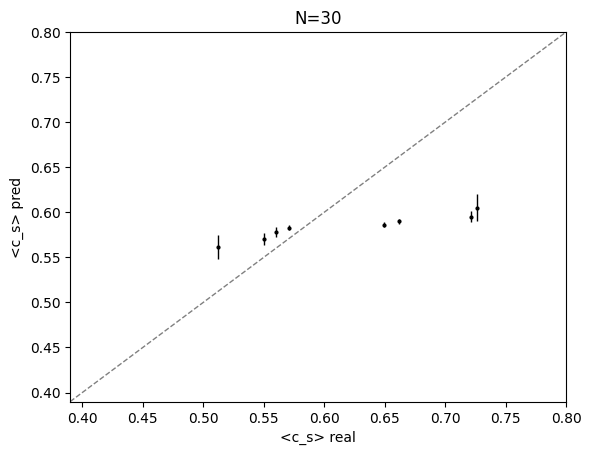

In [30]:
#Plotting predicted vs true mean speed of sound

#join test and hat, to then reorder them and not loose correspondence
data_join = np.empty([len(stat_test), 4])
for i in range(0,len(stat_test)):
    data_join[i] = [stat_test[i,0],stat_test[i,1],stat_hat[i,0],stat_hat[i,1]]

#sort data using np.sort()
data_join = np.sort(data_join, axis=0)

#save indices at new realisation
indices = []
for i in range(0,len(data_join)-1):
    if data_join[i,0] != data_join[i+1,0]:
        indices.append(i)

indices.append(len(data_join)-1)

data_test = np.empty([len(indices), 2])
data_hat = np.empty([len(indices), 2])

produce_mean_cs_overall(indices, data_join, data_test, data_hat)

plot_mean_cs_overall(data_test, data_hat, points, save = False)

Lastly for the regression model, we plot multiple speed of sound predictions for different density nodes.

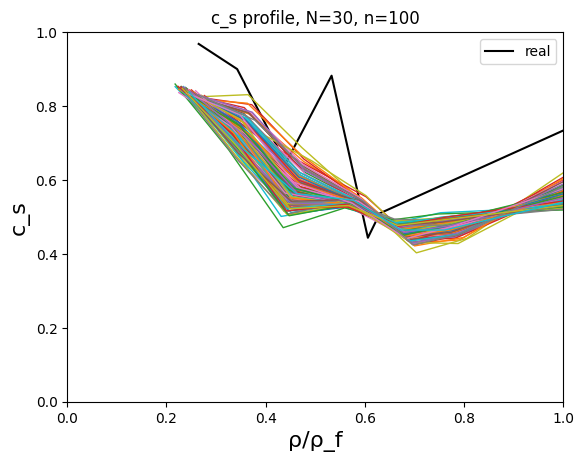

In [31]:
j = 0 #starting point
plot_cs_profile(j, y_test, y_hat, rep_test, points, save = False)

In [32]:
j = 1210 #choose which EOS to save, at an interval of rep_points (10 or 100)

save_EOS(j, y_test, yeos_test, y_hat, yeos_hat, rep_test, points, save = True)

## Feature importance (MRk2 regression model)

In this section we plot a bar plot for feature importance of our regression model. Here we have implemented our own feature importance algorithm, which improves the interpretability of our 'black box' regression neural network. This is informative for future research, since this algorithm lets us probe which feature is worth obtaining more data for during astrophysical research. We implement our feature_importance algorithm by permuting our data and subsequently observing which feature contributes most to our model.

In [33]:
n_iters=10
imp = permutation_importance(model_reg, X_test, y_test, n_iters)
display(imp)

,feature,baseline_loss,mean_permuted_loss,importance
0,M,0.012286,0.012479,0.000192
1,R,0.012286,0.012778,0.000492
2,k2,0.012286,0.012405,0.000119


<Figure size 640x480 with 0 Axes>

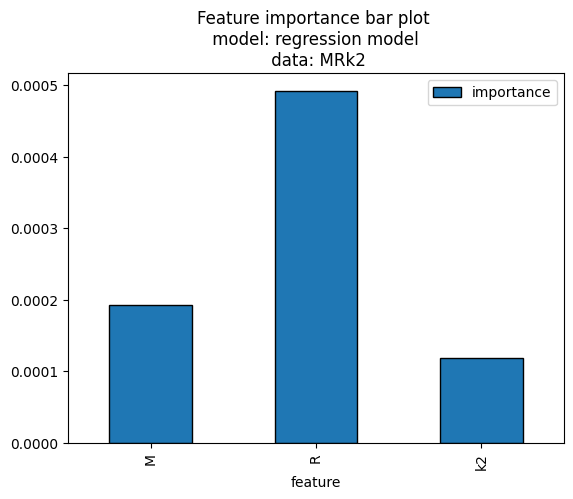

In [34]:
#Plot feature importances with bar plot
plt.figure()
imp.plot.bar(x="feature", y="importance", legend=True, edgecolor='black')
plt.title("Feature importance bar plot \n model: regression model \n data: MRk2")
plt.show()

## Load datasets

Here we load the datasets necessary for our model validation.

In [35]:
ap4 = pd.read_csv("Rescaledap4.dat", sep = r'\s+', header=None)
sly = pd.read_csv("Rescaledsly.dat", sep = r'\s+', header=None)
ap4.columns=['p', 'eps', 'rho']
sly.columns=['p', 'eps', 'rho']

#training data
rho_train = pd.read_csv("matrixrho2.dat", sep = r'\s+', header=None)
cs_train = pd.read_csv("matrixcs2.dat", sep = r'\s+', header=None)
rho_train.columns=['col1', 'col2', 'col3', 'col4', 'col5', 'col6', 'col7']
cs_train.columns=['col1', 'col2', 'col3', 'col4', 'col5', 'col6', 'col7']

#test data
rho_test = pd.read_csv("matrixrhoTest.dat", sep = r'\s+', header=None)
cs_test = pd.read_csv("matrixcsTest.dat", sep = r'\s+', header=None)
rho_test.columns=['col1', 'col2', 'col3', 'col4', 'col5', 'col6', 'col7']
cs_test.columns=['col1', 'col2', 'col3', 'col4', 'col5', 'col6', 'col7']

sly = sly.values
ap4 = ap4.values

rho_train = rho_train.values
cs_train = cs_train.values
rho_test = rho_test.values
cs_test = cs_test.values

We shuffle the dataset to avoid overfitting and filter unphysical data.

In [36]:
dftest_f = dftest.copy().reset_index(drop=True)

#Filter unphysical masses
X_data = dftest_f.iloc[:,16:106].values
unphys_masses = []
points = 30

for i in range(len(X_data)):
    for j in range(len(X_data[1]) - points):
        if X_data[i, j] < 0:
            unphys_masses.append(i)
            break

dftest_f = dftest_f.drop(index=unphys_masses).reset_index(drop=True)

## Plot model validation curves

Here we validate our model. We do this by importing a TOV file generated by generate_data. This TOV file includes a true mass-radius and tidal deformability-mass curve. We use these true curves to benchmark against our predicted curves generated by our model. We do this by filtering our predicted curves by value of EOS label and $\Lambda$.

In [37]:
#TOV file directory
csv_dir = "TOV_sly_-3_40.txt"

In [38]:
z = 1 #file index

#choose these based on csv_dir
eos_name = "sly"
lambda_label = -3

rho_cols = [f"rho{i}" for i in range(1, 8)]
cs_cols  = [f"cs{i}"  for i in range(1, 8)]

Filter predicted data corresponding to our TOV file

In [39]:
#filter data to find relevant prediction data
mask = (dftest_f["eos"] == eos_name) & (dftest_f["Lambda"] == lambda_label)

for i, col in enumerate(rho_cols):
    mask &= np.isclose(dftest_f[col].astype(float).values, float(rho_test[z, i]))

for i, col in enumerate(cs_cols):
    mask &= np.isclose(dftest_f[col].astype(float).values, float(cs_test[z, i]))

data_match = dftest_f[mask].copy().reset_index(drop=False)

Here we rescale our masses and radii back from normalization such that we obtain their observation values, for realistic plot axes.

In [40]:
#Choose row from matched data
row = data_match.iloc[0]

#find obs values and rescale back from normalization
M_obs = row[[f"M{i}" for i in range(1, 31)]].astype(float).values * 3
R_obs = row[[f"R{i}" for i in range(1, 31)]].astype(float).values * 20

In [41]:
def predicted_MR_curve(yrow, eos_label, rho_ref):
    yrow = np.array(yrow, dtype=float)

    #predicted Lambda
    Lambda_root = yrow[0] * 388.0 - 194.0
    Lambda_phys = Lambda_root * ts.Kp * ts.Pu

    #predicted rho and cs
    rho_pts = yrow[1:8] * rho_ref
    cs_pts = yrow[8:15]

    # choose low-density EOS
    if int(eos_label) == 0:
      eos_base = ts.ap4
    else:
      eos_base = ts.sly

    #Building EOS for high-density region
    rho_matrix = rho_pts.reshape(1, 7)
    cs_matrix = cs_pts.reshape(1, 7)

    eos_matrix = np.empty((0, 3))
    eos_matrix = ts.build(
        eos_mat = eos_matrix,
        eos = eos_base,
        matrix_rho = rho_matrix,
        matrix_cs = cs_matrix,
        ds=0,
        rho_treshold = ts.rho_t,
        rho_final = ts.rho_fin)

    p = eos_matrix[:, 0]
    eps = eos_matrix[:, 1]

    eps_fluid_base = interp1d(
        p, eps, kind='linear',
        fill_value="extrapolate",
        bounds_error=False
    )

    deps_dp = np.gradient(eps, p)
    eps_prime_base = interp1d(
        p, deps_dp, kind='linear',
        fill_value='extrapolate',
        bounds_error=False
    )

    ts.Lambda = Lambda_phys
    ts.eps_fluid = eps_fluid_base
    ts.eps_prime = eps_prime_base

    #similar as in data generation file
    eos_end_p = eos_matrix[-1, 0]
    P0 = 2.5e-5

    if ts.Lambda > 0 and eos_end_p > ts.pc:
        Pf = eos_end_p - ts.Lambda
    else:
        Pf = eos_end_p

    data_matrix = np.empty((0, 4))
    data_matrix = ts.cycle_tov(data_matrix, P0, Pf)

    R = data_matrix[:, 2]
    M = data_matrix[:, 1]

    return R, M, data_matrix

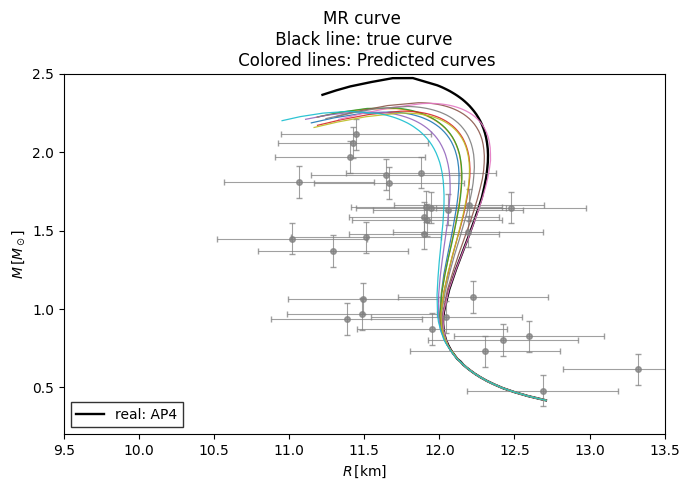

In [42]:
plt.figure(figsize=(7, 5))

#load and plot true data
tov = np.loadtxt(csv_dir)
plt.plot(
    tov[:, 2], tov[:, 1],
    color="black", lw=1.7,
    label=r"real: AP4")

#plot noisy observation points
plt.errorbar(
    R_obs, M_obs,
    xerr=0.5, yerr=0.1,
    fmt="o",
    ms=4,
    color="gray",
    ecolor="gray",
    elinewidth=0.8,
    capsize=2,
    alpha=0.75)

#predicted curves indices
indices_j = data_match["index"].iloc[:10].to_list()

for j in indices_j:
    R_pred, M_pred, data_matrix, = predicted_MR_curve(
        yrow=y_hat[j],
        eos_label=yeos_hat[j],
        rho_ref=ts.rho_fin)
    plt.plot(R_pred, M_pred, lw=0.9, alpha=0.9)

plt.title("MR curve \n Black line: true curve \n Colored lines: Predicted curves")
plt.xlabel(r"$R\,[\mathrm{km}]$")
plt.ylabel(r"$M\,[M_\odot]$")

plt.xlim(9.5, 13.5)
plt.ylim(0.2, 2.5)
plt.xticks()
plt.yticks()

plt.grid(False)

plt.legend(
    loc="lower left",
    frameon=True,
    fancybox=False,
    edgecolor="black")

plt.tight_layout()
plt.show()

The black curve represents the true MR curve obtained from our TOV_solver.py, while the colored curves correspond to the predicted MR curves. The points denote our observation points including uncertainty bars. As the mass $M$ increases, we can observe that the predicted curves begin to deviate from the true curve. This behavior is expected, because more massive neutron stars reach higher core densities. This implies that a larger part of the structure probes the high-density region of the star. Since we have concluded that our regression model captures only a weak signal for the high-density region of the neutron star, the predictions become less accurate for a higher mass $M$.

Now we proceed to the k2-mass curve. This is obtained by first determining $k_2$ from our parameter $\Lambda$.

In [43]:
#k2 calculation for k2M curve
def k2(data_matrix):
    M = data_matrix[:,1]
    R = data_matrix[:,2]
    lam = data_matrix[:,3]

    k2 = 1.5 * lam * (M / (R * ts.KK))**5
    return M, k2

Here we plot the $k_2,M$ curve.

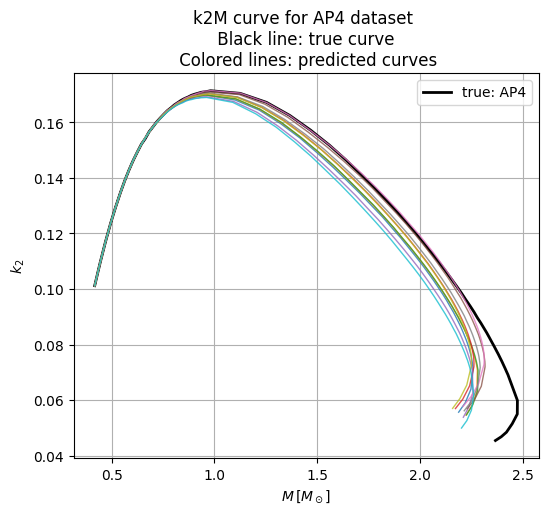

In [44]:
M_true, k2_true = k2(tov)

plt.figure(figsize=(6,5))
plt.plot(M_true, k2_true, color="black", lw=2, label="true: AP4")

for j in indices_j:
    R_pred, M_pred, data_matrix= predicted_MR_curve(
        yrow=y_hat[j],
        eos_label=yeos_hat[j],
        rho_ref=ts.rho_fin)

    M_pred, k2_pred = k2(data_matrix)

    plt.plot(M_pred, k2_pred, lw=1.0, alpha=0.8)

plt.xlabel(r"$M\,[M_\odot]$")
plt.ylabel(r"$k_2$")
plt.title("k2M curve for AP4 dataset \n Black line: true curve \n Colored lines: predicted curves")
plt.grid()
plt.legend()
plt.show()

Here the black curve corresponds to the true curve and the colored lines correspond to the predicted curves. We observe a slight deviation in the predicted curves as mass $M$ increases. This can be again attributed to the fact that higher-mass neutron stars probe deeper into the high-density region of the neutron star, where our regression model does not capture a strong signal.

## Bayesian regression network modelling

While the deterministic neural network described above provides point estimates for the EOS parameters, it does not directly quantify the uncertainty associated with the predictions. This is especially unfortunate for our regression model, since it captured only a weak signal. To address this limitation, we also consider a Bayesian neural network (BNN), in which the network weights are treated as probability distributions rather than fixed parameters. Instead of learning a single set of weights, the model learns a posterior distribution over the weights conditioned on the training data.

In practice, we implement this Bayesian formulation using TensorFlow Probability, where each weight is represented by a learnable probability distribution rather than a fixed value. The Bayesian layers are implemented using variational dense layers $\texttt{DenseVariational}$, which allow the network to learn an approximate posterior distribution over the weights during training. We assume a standard normal prior over the weights, while the posterior distribution is modeled as a trainable multivariate normal distribution.

The architecture of the Bayesian network follows that of the deterministic regression model. The network consists of four hidden layers, each containing 16 neurons with LeakyReLU activation functions.

In [45]:
X, y = df_MRk2.values[:,16:106], df_MRk2.values[:,0:16]

In [46]:
#Labelencode column 0
y[:,0] =  LabelEncoder().fit_transform(y[:,0])

#Normalize columns
y[:,1] = (y[:,1] + 194.)/388.
y[:,2:9] /= y[0,8]

y = y[:,1:16]

In [47]:
#Ensure all data are floating point values
X, y = X.astype('float32'), y.astype('float32')
print(X.shape, y.shape)

(259500, 90) (259500, 15)


In [48]:
#Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Lambda_values_test = y_test[:,0]

(173865, 90) (85635, 90) (173865, 15) (85635, 15)


Modelling

Epoch 1/45
5434/5434 [==============================] - 181s 32ms/step - loss: 1545.7046 - accuracy: 0.0710
Epoch 2/45
5434/5434 [==============================] - 173s 32ms/step - loss: 598.6462 - accuracy: 0.0648
Epoch 3/45
5434/5434 [==============================] - 193s 35ms/step - loss: 311.0756 - accuracy: 0.0678
Epoch 4/45
5434/5434 [==============================] - 184s 34ms/step - loss: 159.9393 - accuracy: 0.0692
Epoch 5/45
5434/5434 [==============================] - 197s 36ms/step - loss: 88.8366 - accuracy: 0.0710
Epoch 6/45
5434/5434 [==============================] - 201s 37ms/step - loss: 51.5257 - accuracy: 0.0732
Epoch 7/45
5434/5434 [==============================] - 189s 35ms/step - loss: 30.7727 - accuracy: 0.0708
Epoch 8/45
5434/5434 [==============================] - 212s 39ms/step - loss: 18.7753 - accuracy: 0.0736
Epoch 9/45
5434/5434 [==============================] - 190s 35ms/step - loss: 12.0157 - accuracy: 0.0715
Epoch 10/45
5434/5434 [==================

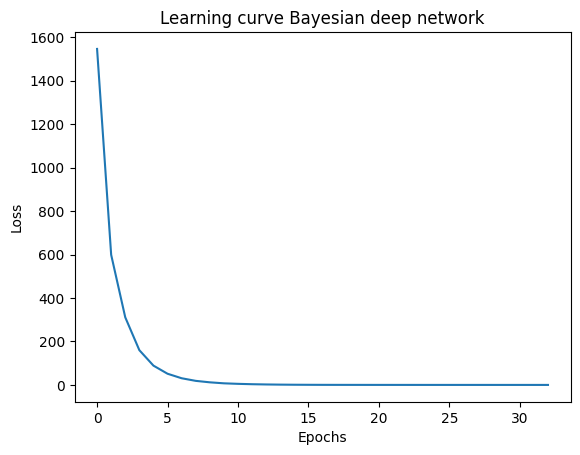

In [49]:
#Hyperparameters
activation = 'LeakyReLU' #We can choose from: 'LeakyReLU', 'relu', 'sigmoid'
units = 16
epochs = 45
train_data = [X_train, y_train]
test_data = [X_test, y_test]

#Build model
model = produce_model(train_data, units, activation, get_prior, get_posterior, activation_last_layer=False)

#Compile model
model.compile(optimizer=tf_keras.optimizers.RMSprop(learning_rate=0.0001), loss='mse', metrics=['accuracy'])

#Callback at chosen accuracy
callback = training_stop(terminate_at_accuracy = 0.7)

#Model fitting
history = model.fit(X_train,y_train, epochs=epochs, verbose=1, callbacks = [callback])

#Learning curve
plt.plot(history.history['loss'])
plt.title("Learning curve Bayesian deep network")
plt.xlabel('Epochs')
plt.ylabel('Loss');

## Bayesian regression network plots

Here we plot the results of our Bayesian regression model. We do this by first plotting a speed of sound plot against the mass. We plot the sampling of our BNN with a mean including uncertainty ranges. In the same plot, we include the true speed of sound values (red crosses) to conclude whether the BNN provides a reasonable distribution with respect to the true values.

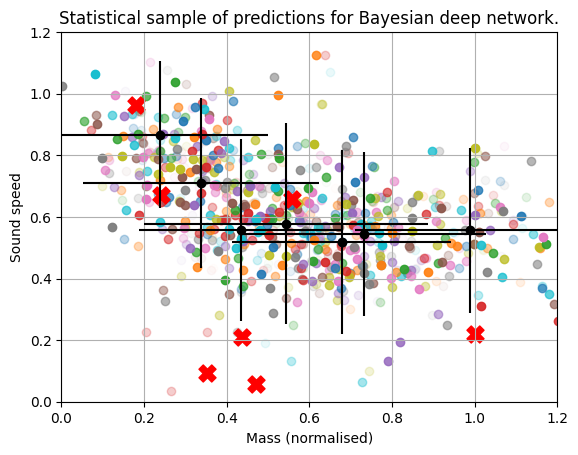

In [50]:
i00 = 100 #pick up input point
X_test00 = X_test[i00] #define array with input data

#produce output sample
sample00 = produce_sample_cs(X_test00, model_def = model, n_samples = 100, check_range=False)

#plot results
produce_sample_plot(sample00)

#include axis vals greater than normalization(>1) due to probabilistic sampling
plt.xlim(0, 1.2)
plt.ylim(0, 1.2)

plt.title("Statistical sample of predictions for Bayesian deep network.")
plt.grid()
plt.scatter(y_test[i00][1:8], y_test[i00][8:15], marker = "X", color = 'red', s = 150)
plt.savefig('cs-mass_i100-n100.png', bbox_inches='tight')

From the above plot we can plot the distribution of the speed of sound for different density notes denoted by different colors.

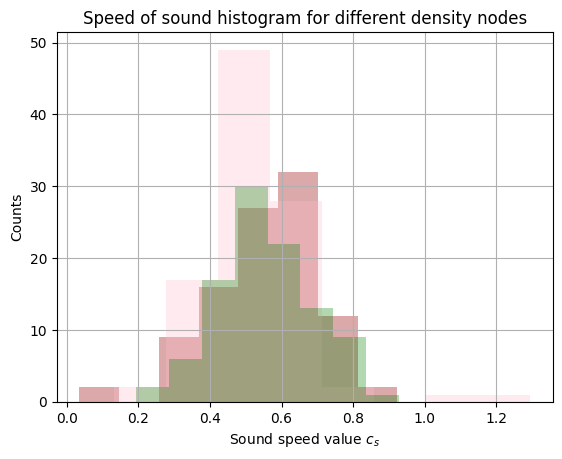

In [51]:
# Histograms for speed of sound
i00 = 100
X_test00 = X_test[i00]
bins = 8

data12 = sample00[:,2][:,1]
data22 = sample00[:,4][:,1]
data32 = sample00[:,6][:,1]
plt.hist(data12, bins = bins, color = "brown", alpha = 0.4)
plt.hist(data22, bins = bins, color = "pink", alpha = 0.3)
plt.hist(data32 ,bins = bins, color = "green", alpha = 0.3)
plt.grid()

plt.title("Speed of sound histogram for different density nodes")
plt.xlabel(r"Sound speed value $c_s$")
plt.ylabel("Counts")
plt.savefig('histo_cs_i100-n100.png', bbox_inches='tight')

The same can be done for the mass value. We plot the histograms for the mass distribution. This helps us to distinguish how the mass changes for various density nodes.

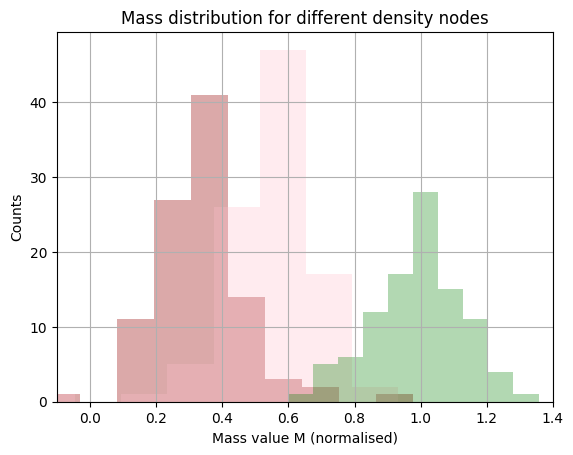

In [52]:
#Mass histograms
i00 = 100
X_test00 = X_test[i00]
bins = 10

data11  = sample00[:,1][:,0]
data21  = sample00[:,3][:,0]
data31  = sample00[:,6][:,0]
plt.hist(data11, bins = bins, color = "brown", alpha = 0.4)
plt.hist(data21 , bins = bins, color = "pink", alpha = 0.3)
plt.hist(data31 ,bins = bins, color = "green", alpha = 0.3)
plt.grid()
plt.xlim(-0.1,1.4)
plt.title("Mass distribution for different density nodes")
plt.xlabel("Mass value M (normalised)")
plt.ylabel("Counts")
plt.savefig('histo_mass_i100-n100.png', bbox_inches='tight')